In [16]:
#1.Explorarea setului de dat
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
y = iris.target

print("Număr de exemple:", X.shape[0])
print("Număr de caracteristici:", X.shape[1])
print("\nDenumirile caracteristicilor:")
print(iris.feature_names)
print("\nClasele:")
print(iris.target_names)

Număr de exemple: 150
Număr de caracteristici: 4

Denumirile caracteristicilor:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Clasele:
['setosa' 'versicolor' 'virginica']


In [17]:
#2. Împărțirea setului în date de antrenament și testare
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(120, 4)
(30, 4)
(120,)
(30,)


In [18]:
#3. Preprocesarea datelor
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Înainte de scalare ")
print(X_train[:3])
print("\n După scalare ")
print(X_train_scaled[:3])


 Înainte de scalare 
[[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]]

 După scalare 
[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]]


In [19]:
#4. Construirea și antrenarea modelului KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print(f"Acuratete: {acc}")

Acuratete: 1.0


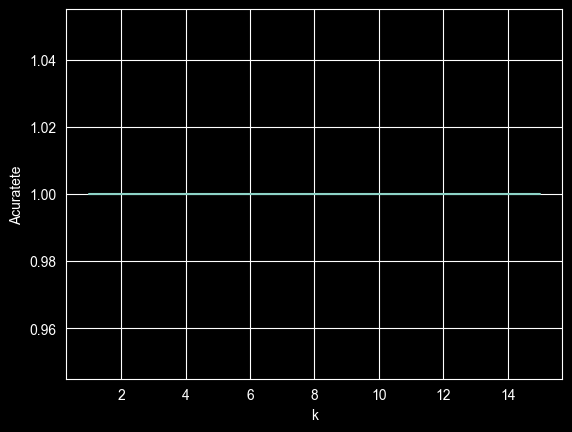

Valoarea optima pentru k este: 1


In [20]:
#5. Explorarea impactului valorii k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies = []

for k in range(1, 16):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 16), accuracies)
plt.xlabel("k")
plt.ylabel("Acuratete")
plt.show()

best_k = accuracies.index(max(accuracies)) + 1
print(f"Valoarea optima pentru k este: {best_k}")

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Matricea de confuzie:")
print(confusion_matrix(y_test, y_pred))

print("\nRaport de clasificare:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Matricea de confuzie:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Raport de clasificare:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Floarea este: setosa


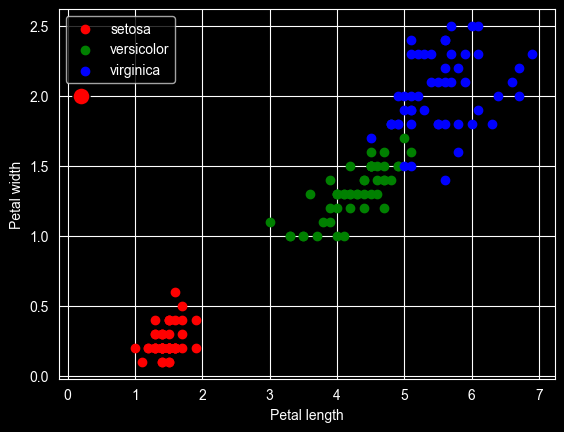

In [28]:
#7. Vizualizarea datelor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X = iris.data
y = iris.target

X2 = X[:, 2:4]

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X2, y)

colors = ['red', 'green', 'blue']

for i in range(3):
    plt.scatter(X2[y == i, 0], X2[y == i, 1], color=colors[i], label=iris.target_names[i])

pl = float(input("Lungime petala: "))
pw = float(input("Latime petala: "))

sample = np.array([[pl, pw]])

pred = knn.predict(sample)

print(f"Floarea este: {iris.target_names[pred][0]}")

plt.scatter(pl, pw, color=colors[pred[0]], s=150, edgecolor='black')

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend()
plt.show()